# Geometric Brownian Motion Demo

Original QMCPy demo: [`QMCPy/demos/GBM/gbm_demo.ipynb`](../../QMCPy/demos/GBM/gbm_demo.ipynb)

Demonstrates GeometricBrownianMotion for financial modeling:
  S(t) = S₀ exp[(γ - σ²/2) t + σ W(t)]

where W(t) is a standard Brownian motion.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/gbm_demo.ipynb)

In [1]:
using QMC
using Statistics
using Printf

# Plots.jl is optional; guard plot cells so the notebook runs in headless CI.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


Basic GBM Sample Generation

In [2]:
println("="^60)
println("GeometricBrownianMotion: Basic Usage")
println("="^60)

d = 4           # 4 time steps
S0 = 100.0      # initial price
γ = 0.05        # drift (5% annual return)
σ2 = 0.04       # diffusion (volatility² = 20% vol)

dd = DigitalNetB2(d; seed=7)
gbm = GeometricBrownianMotion(dd;
    t_final=1.0, initial_value=S0, drift=γ, diffusion=σ2)

println("  $gbm")
println("  Time vector: t = [$(join([@sprintf("%.2f", t) for t in gbm.time_vector], ", "))]")
println()

n = 10_000
x = gen_samples(dd, n)
paths = transform(gbm, x)

println("  Generated $n sample paths")
println("  Path shape: $(size(paths))")
println()

GeometricBrownianMotion: Basic Usage
  GeometricBrownianMotion(d=4, S₀=100.0, γ=0.05, σ²=0.04)


  Time vector: t = [0.25, 0.50, 0.75, 1.00]

  Generated 10000 sample paths


  Path shape: (10000, 4)



Show a few sample paths

In [3]:
println("  First 5 paths (S₀, S(t₁), S(t₂), S(t₃), S(T)):")
for i in 1:5
    @printf("    Path %d: %6.2f → [%6.2f  %6.2f  %6.2f  %6.2f]\n",
            i, S0, paths[i,1], paths[i,2], paths[i,3], paths[i,4])
end
println()

  First 5 paths (S₀, S(t₁), S(t₂), S(t₃), S(T)):
    Path 1: 100.00 → [ 85.62   92.05   83.53   77.14]
    Path 2: 100.00 → [ 95.39   94.21  106.62  117.46]


    Path 3: 100.00 → [110.73   95.91   95.74   91.52]
    Path 4: 100.00 → [102.05  113.43  121.68  126.68]
    Path 5: 100.00 → [104.42   94.43   82.58   91.10]



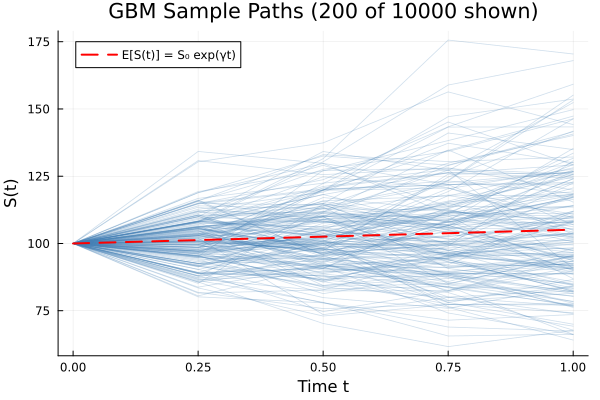

In [4]:
if HAVE_PLOTS
    t_plot = [0.0; gbm.time_vector]
    n_plot = min(200, size(paths, 1))
    S_with_origin = hcat(fill(S0, n_plot), paths[1:n_plot, :])  # n_plot × (d+1)
    p = plot(t_plot, S_with_origin';
        alpha=0.25, color=:steelblue, lw=0.8, label=nothing,
        xlabel="Time t", ylabel="S(t)",
        title="GBM Sample Paths ($(n_plot) of $n shown)")
    # theoretical mean E[S(t)] = S0 exp(γ t)
    E_S = S0 .* exp.(γ .* gbm.time_vector)
    plot!([0.0; gbm.time_vector], [S0; E_S];
        color=:red, lw=2, linestyle=:dash, label="E[S(t)] = S₀ exp(γt)")
    display(p)
end


Statistical Properties

In [5]:
println("="^60)
println("Statistical Properties of GBM")
println("="^60)

Statistical Properties of GBM


E[S(t)] = S₀ exp(γ t)

In [6]:
for j in 1:d
    t = gbm.time_vector[j]
    exact_mean = S0 * exp(γ * t)
    empirical_mean = mean(paths[:, j])
    @printf("  t = %.2f: E[S(t)] = %.2f (exact = %.2f, err = %.2f%%)\n",
            t, empirical_mean, exact_mean,
            100.0 * abs(empirical_mean - exact_mean) / exact_mean)
end
println()

  t = 0.25: E[S(t)] = 101.26 (exact = 101.26, err = 0.00%)
  t = 0.50: E[S(t)] = 102.53 (exact = 102.53, err = 0.00%)
  t = 0.75: E[S(t)] = 103.82 (exact = 103.82, err = 0.00%)
  t = 1.00: E[S(t)] = 105.12 (exact = 105.13, err = 0.00%)



GBM values must be positive

In [7]:
@printf("  All values positive: %s (min = %.4f)\n",
        all(paths .> 0) ? "YES" : "NO", minimum(paths))
println()

  All values positive: YES (min = 52.1648)



GBM with FinancialOption

In [8]:
println("="^60)
println("GBM + FinancialOption Integration Pipeline")
println("="^60)

d_opt = 52
dd_opt = IIDStdUniform(d_opt; seed=7)

GBM + FinancialOption Integration Pipeline


IIDStdUniform(d=52)

Using BrownianMotion (internal GBM construction in FinancialOption)

In [9]:
tm_bm = BrownianMotion(dd_opt)
f_bm = FinancialOption(tm_bm;
    option_type=:asian, call_put=:call, mean_type=:arithmetic,
    volatility=0.2, start_price=100.0, strike_price=100.0,
    interest_rate=0.05)
sc_bm = CubMCCLT(f_bm; abs_tol=0.1, n_init=32768)
result_bm = integrate(sc_bm)
@printf("  Asian Call (via BM):  %.4f  (n = %d)\n", result_bm.solution, result_bm.data[:n])

┌ Warning: CubMCCLT: did not converge within n_max=1073741824. Error bound: 0.10008854209961651, tolerance: 0.1
└ @ QMC ~/Documents/ProgramData/QMCSoftware_space/QMC.jl/src/stopping_criterion/cub_mc_clt.jl:156


  Asian Call (via BM):  5.8750  (n = 95793)


Using GeometricBrownianMotion directly

In [10]:
dd_opt2 = IIDStdUniform(d_opt; seed=7)
gbm_tm = GeometricBrownianMotion(dd_opt2;
    t_final=1.0, initial_value=100.0, drift=0.05, diffusion=0.04)
f_gbm = FinancialOption(gbm_tm;
    option_type=:asian, call_put=:call, mean_type=:arithmetic,
    volatility=0.2, start_price=100.0, strike_price=100.0,
    interest_rate=0.05)
sc_gbm = CubMCCLT(f_gbm; abs_tol=0.1, n_init=32768)
result_gbm = integrate(sc_gbm)
@printf("  Asian Call (via GBM): %.4f  (n = %d)\n", result_gbm.solution, result_gbm.data[:n])
println()

┌ Warning: CubMCCLT: did not converge within n_max=1073741824. Error bound: 0.10008854209961646, tolerance: 0.1
└ @ QMC ~/Documents/ProgramData/QMCSoftware_space/QMC.jl/src/stopping_criterion/cub_mc_clt.jl:156


  Asian Call (via GBM): 5.8750  (n = 95793)



Different Volatilities

In [11]:
println("="^60)
println("European Call Prices for Different Volatilities")
println("="^60)

for vol in [0.1, 0.2, 0.3, 0.5, 0.8]
    dd_v = IIDStdUniform(52; seed=7)
    tm_v = BrownianMotion(dd_v)
    f_v = FinancialOption(tm_v;
        option_type=:european, call_put=:call,
        volatility=vol, start_price=100.0, strike_price=100.0,
        interest_rate=0.05)
    sc_v = CubMCCLT(f_v; abs_tol=5.0, n_init=4096)
    result_v = integrate(sc_v)
    @printf("  σ = %.1f: European Call = %.2f\n", vol, result_v.solution)
end
println()

println("="^60)
println("GBM demo completed!")

European Call Prices for Different Volatilities
  σ = 0.1: European Call = 6.78
  σ = 0.2: European Call = 10.43
  σ = 0.3: European Call = 14.25
  σ = 0.5: European Call = 21.97


  σ = 0.8: European Call = 33.47

GBM demo completed!


## Sampler Comparison: Terminal Mean Error


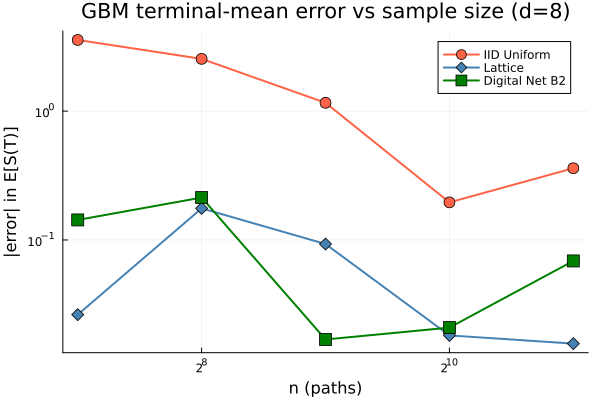

In [12]:
if HAVE_PLOTS
    d_cmp = 8
    ns_cmp = 2 .^ (7:11)
    exact_T = S0 * exp(γ * 1.0)
    function gbm_mae(dd)
        tm = GeometricBrownianMotion(dd; t_final=1.0, initial_value=S0, drift=γ, diffusion=σ2)
        x = transform(tm, gen_samples(dd, ns_cmp[end]))
        [abs(mean(x[1:n, end]) - exact_T) for n in ns_cmp]
    end
    iid_err = gbm_mae(IIDStdUniform(d_cmp; seed=7))
    lat_err = gbm_mae(Lattice(d_cmp; seed=7))
    net_err = gbm_mae(DigitalNetB2(d_cmp; seed=7, graycode=false))

    p = plot(ns_cmp, iid_err;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:tomato, label="IID Uniform",
        xlabel="n (paths)", ylabel="|error| in E[S(T)]",
        title="GBM terminal-mean error vs sample size (d=$d_cmp)")
    plot!(ns_cmp, lat_err; marker=:diamond, lw=2, ms=6, color=:steelblue, label="Lattice")
    plot!(ns_cmp, net_err; marker=:square,  lw=2, ms=6, color=:green, label="Digital Net B2")
    display(p)
end
